# LST Thermal — 1 m Sharpened Temperature (Celsius)

Sentinel-2 has no thermal band. LST is **measured** by Landsat 8/9 Collection 2 L2 `ST_B10` (30 m, `K=DN×0.00341802+149.0`) and sharpened to your 1 m `MS.tif` grid via TsHARP: `LST_30m = a+b·NDVI_30m` (least squares on clear 30 m pixels) + bilinear residuals → `LST_1m = a+b·NDVI_1m + resid_1m`. Preserves coarse means. Output: `indices/thermal/lst.tiff` float32 **Celsius** (K−273.15), NoData=NaN, plus `lst_legend.json`.


## 0. AWS config — required for LST (usgs-landsat is Requester Pays)

Without this, LST is skipped with `aws-credentials` note and the run still succeeds. Three ways (pick one):
1. **Env vars** (temporary, for this shell/notebook): `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_SESSION_TOKEN` (if STS)
2. **File** `~/.aws/credentials` (persistent):
   ```ini
   [default]
   aws_access_key_id = ...
   aws_secret_access_key = ...
   # aws_session_token = ...  # if temporary
   ```
3. **Instance role** (EC2) — no config needed

Reads are windowed COG range requests (KB-scale, fractions of a cent). Verify below.

In [1]:
import os, pathlib, json, subprocess, sys
from pathlib import Path
print("Env:", {k: ("***"+v[-4:] if v else "unset") for k,v in {
    "AWS_ACCESS_KEY_ID": os.environ.get("AWS_ACCESS_KEY_ID",""),
    "AWS_SECRET_ACCESS_KEY": os.environ.get("AWS_SECRET_ACCESS_KEY",""),
    "AWS_SESSION_TOKEN": os.environ.get("AWS_SESSION_TOKEN",""),
}.items()})
creds = Path.home() / ".aws" / "credentials"
print("~/.aws/credentials exists:", creds.exists())
if creds.exists():
    print(creds.read_text().splitlines()[0][:40])
# quick boto check if available
try:
    import botocore.session
    sess = botocore.session.Session()
    print("botocore credentials:", sess.get_credentials() is not None)
except Exception as e:
    print("botocore not installed or no creds:", e)
# optional: set from notebook (uncomment, paste, run, then clear)
# os.environ["AWS_ACCESS_KEY_ID"] = "ASIA..."
# os.environ["AWS_SECRET_ACCESS_KEY"] = "..."
# os.environ["AWS_SESSION_TOKEN"] = "..."  # if STS
# print("set")


Env: {'AWS_ACCESS_KEY_ID': 'unset', 'AWS_SECRET_ACCESS_KEY': 'unset', 'AWS_SESSION_TOKEN': 'unset'}
~/.aws/credentials exists: False


botocore credentials: False


In [2]:
# Test the S3 path without downloading a full scene (small 30 m window)
import rasterio
# This will raise LSTUnavailable(aws-credentials) if creds are missing — expected
try:
    from pathlib import Path
    import sys; sys.path.insert(0, str(Path.cwd().parent / "scripts"))
    if not (Path.cwd() / "scripts" / "lst.py").exists():
        sys.path.insert(0, "/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/scripts")
    import lst
    print("lst.ST_MULT", lst.ST_MULT_USGS, "230–360 K gate", lst.PLAUSIBLE_K_MIN, lst.PLAUSIBLE_K_MAX)
    # dry check — does not hit S3
    print("search window for 2026-08-14:", lst.window_range("2026-08-14"))
except Exception as e:
    print(e)


lst.ST_MULT 0.00341802 230–360 K gate 230.0 360.0
search window for 2026-08-14: ('2026-07-29', '2026-08-15')


## 1. Setup — find latest run with thermal

In [3]:
from pathlib import Path
import glob
ROOT = Path.cwd()
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path.cwd().parent
if not (ROOT / "scripts" / "run_location.py").exists():
    ROOT = Path("/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core")
cands = sorted(glob.glob(str(ROOT / "outputs" / "*" / "*" / "*")))
run_dir = Path(cands[-1]) if cands else None
print(run_dir)
MS = run_dir / "MS.tif" if run_dir else None
LST = run_dir / "indices" / "thermal" / "lst.tiff" if run_dir else None
print("MS", MS.exists() if MS else False, "LST", LST.exists() if LST else False)
if LST and LST.exists():
    import rasterio
    with rasterio.open(LST) as s:
        print(f"LST {s.width}x{s.height} {s.dtypes[0]} {s.descriptions[0]} {s.tags().get('LST_UNITS')}")
        print(s.tags(1).get("LST_LEGEND","")[:120])
else:
    print("No LST — rerun with creds: AWS_ACCESS_KEY_ID=... python scripts/run_location.py --lon 10.641 --lat 35.8256 --date 2026-08-14")


/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core/outputs/TN/2026-08-14/inf-20260922T131756Z-35.82560N-10.64100E-60e8
MS True LST True
LST 4120x4120 float32 LST (Celsius) Celsius
LST 1 m (Celsius, NoData=NaN) — min 9.16 C (282.31 K), max 63.55 C (336.70 K), mean 38.33 C, median 41.45 C, p2 28.05 C,


## 2. Visualize — LST (Celsius) + NDVI (1 m)

/tmp/ipykernel_111289/117210779.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


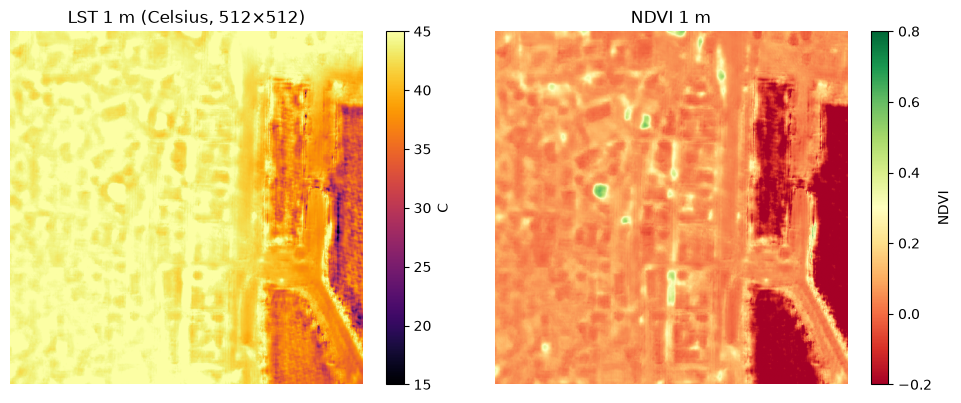

LST 12.1–58.1 C  mean 42.5  NDVI 0.034


In [4]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if LST and LST.exists():
    w=512; y0,x0=2048-256,2048-256
    with rasterio.open(LST) as s:
        lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        ndvi=np.where((dn[3]+dn[2])==0, np.nan, (dn[3]-dn[2])/(dn[3]+dn[2]))
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    im=ax[0].imshow(lst, cmap="inferno", vmin=15, vmax=45); plt.colorbar(im, ax=ax[0], label="C"); ax[0].set_title("LST 1 m (Celsius, 512×512)"); ax[0].axis("off")
    im=ax[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8); plt.colorbar(im, ax=ax[1], label="NDVI"); ax[1].set_title("NDVI 1 m"); ax[1].axis("off")
    plt.tight_layout(); plt.show()
    print(f"LST {np.nanmin(lst):.1f}–{np.nanmax(lst):.1f} C  mean {np.nanmean(lst):.1f}  NDVI {np.nanmean(ndvi):.3f}")
else:
    print("Need LST")


## 3. Chart — LST histogram (Celsius) + legend

LST 1 m (Celsius, NoData=NaN) — min 9.16 C (282.31 K), max 63.55 C (336.70 K), mean 38.33 C, median 41.45 C, p2 28.05 C, p98 50.72 C; per-pixel value = temperature at that 1 m ground cell in Celsius
units Celsius  min 9.16021728515625 max 63.549560546875
sidecar True


/tmp/ipykernel_111289/1460186566.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1); tags=s.tags()


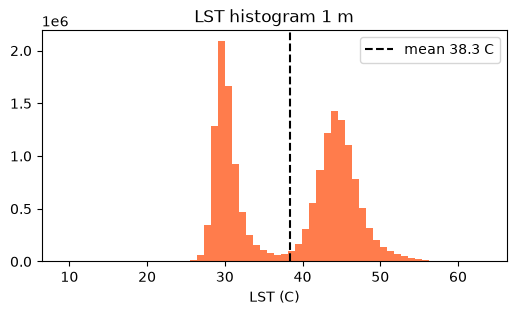

LST 1 m (Celsius, NoData=NaN) — min 9.16 C (282.31 K), max 63.55 C (336.70 K), mean 38.33 C, median 41.45 C, p2 28.05 C, p98 50.72 C; per-pixel value = temperature at that 1 m ground cell in Celsius


In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt, json
from pathlib import Path
if LST and LST.exists():
    with rasterio.open(LST) as s:
        lst=s.read(1); tags=s.tags()
        legend=s.tags(1).get("LST_LEGEND","")
        print(legend)
        print(f"units {tags.get('LST_UNITS')}  min {tags.get('LST_MIN_C')} max {tags.get('LST_MAX_C')}")
        print(f"sidecar {Path(LST).with_name('lst_legend.json').exists()}")
        m=np.isfinite(lst)
        plt.figure(figsize=(6,3)); plt.hist(lst[m].ravel(), bins=60, color="orangered", alpha=0.7); plt.axvline(np.nanmean(lst), color="black", ls="--", label=f"mean {np.nanmean(lst):.1f} C"); plt.legend(); plt.xlabel("LST (C)"); plt.title("LST histogram 1 m"); plt.show()
    # also show sidecar
    print(json.loads(Path(LST).with_name("lst_legend.json").read_text())["legend"])


## 4. LST vs NDVI — 2D histogram + fit (TsHARP diagnostics)
The run README records the fit: `LST = intercept + slope·NDVI` over ~5k clear 30 m pixels, RMSE in K. This cell reproduces the scatter at 1 m.

1 m fit: LST = 41.92 + 22.27·NDVI  (compare to 30 m fit in run README)


/tmp/ipykernel_111289/2948349775.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))


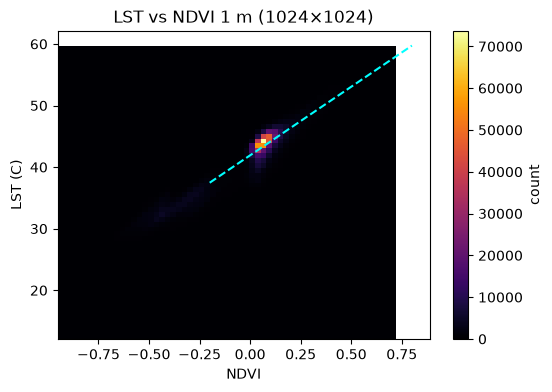

In [6]:
import rasterio, numpy as np, matplotlib.pyplot as plt
if LST and LST.exists():
    w=1024; y0,x0=2048-512,2048-512
    with rasterio.open(MS) as s:
        dn=s.read(window=rasterio.windows.Window(x0,y0,w,w)).astype(float)/10000
        ndvi=np.where((dn[3]+dn[2])==0, np.nan, (dn[3]-dn[2])/(dn[3]+dn[2]))
    with rasterio.open(LST) as s:
        lst=s.read(1, window=rasterio.windows.Window(x0,y0,w,w))
    m=np.isfinite(ndvi)&np.isfinite(lst)
    # linear fit at 1 m (diagnostic, not the 30 m fit)
    slope, intercept = np.polyfit(ndvi[m].ravel(), lst[m].ravel(), 1)
    print(f"1 m fit: LST = {intercept:.2f} + {slope:.2f}·NDVI  (compare to 30 m fit in run README)")
    plt.figure(figsize=(6,4)); plt.hist2d(ndvi[m], lst[m], bins=60, cmap="inferno"); plt.colorbar(label="count"); plt.plot([-0.2,0.8], [intercept+slope*(-0.2), intercept+slope*0.8], color="cyan", ls="--"); plt.xlabel("NDVI"); plt.ylabel("LST (C)"); plt.title("LST vs NDVI 1 m (1024×1024)"); plt.show()
else:
    print("Need LST")


## 5. If LST is missing — generate it on the existing MS.tif (needs AWS creds)
No need to re-run the 5 min S2SR. This cell sharpening-only on the already super-resolved cube.

In [7]:
# from pathlib import Path
# import sys; sys.path.insert(0, str(ROOT / "scripts"))
# from lst import compute_lst
# import sys; sys.path.insert(0, str(ROOT / "scripts" / "local_engine"))
# import datautils
# # Use the run's center lon/lat — read from run README or set manually
# # lon, lat = 10.641, 35.8256
# # aoi = datautils.aoi_from_xy((lon, lat), km=6)
# # rec = compute_lst(MS, "2026-08-14", aoi["bbox"])
# # print(rec)
print("Uncomment and set lon/lat/date + AWS creds, then run")


Uncomment and set lon/lat/date + AWS creds, then run
